lsgo

#1 spectral diff 1d

In [ ]:
import numpy as np
L = 128        # System size
N = 3000       # Total no. of iterations
delt = 0.1     # temporal step size/resolution
delx = 0.3     # spatial step size/resolution
D = 0.005      # Diffusion constant

c = np.zeros(L)
c0 = np.zeros(L)
K = (2 * np.pi / (L * delx)) * np.concatenate((
    np.arange(0, L//2),
    np.arange(-L//2, 0)
))

# Spatial grid
x = np.arange(1, L + 1)

# Gaussian initial condition
c0 = np.exp(-((x - L/2) * delx / 5)**2)
c = c0.copy()

# FFT
cc = np.fft.fft(c)

# Storage for time evolution
cT = np.zeros((L, N))

# Time loop
for i in range(N):
    for p in range(L):
        cc[p] = cc[p] - D * delt * (K[p]**2) * cc[p]
    # Vectorized alternative (same as commented MATLAB line):
    # cc = cc - D * delt * (K**2) * cc

    cT[:, i] = np.real(np.fft.ifft(cc))

# Optional parameter
Neumann_par = D * delt / (delx * delx)

#2 spectral advection   

In [1]:
import numpy as np

# Parameters
L = 128        # System size
N = 3000       # Total no. of iterations
delt = 0.01    # temporal step size (smaller than diffusion for stability)
delx = 0.3     # spatial step size

# Arrays
y = np.zeros(L)
y0 = np.zeros(L)

# k modes (same construction)
K = (2 * np.pi / (L * delx)) * np.concatenate((
    np.arange(0, L//2),
    np.arange(-L//2, 0)
))

# Spatial grid
x = np.arange(1, L + 1)

# Initial condition (Gaussian pulse)
y0 = np.exp(-((x - L/2) * delx / 5)**2)
y = y0.copy()

# FFT
yy = np.fft.fft(y)

# Storage
yT = np.zeros((L, N))

# Time loop
for i in range(N):
    for p in range(L):
        yy[p] = yy[p] + delt * (1j * K[p]) * yy[p]
    # Vectorized version:
    # yy = yy + delt * (1j * K) * yy

    yT[:, i] = np.real(np.fft.ifft(yy))

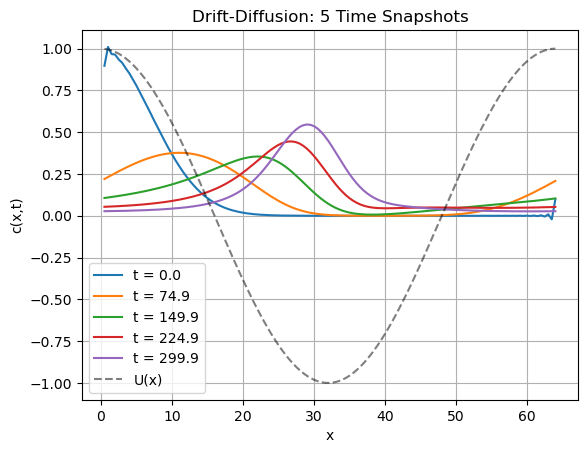

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
delt = 0.1    # temporal resolution
delx = 0.5    # spatial resolution
D = 0.15      # diffusion constant
L = 128       # system size
N = 3000      # number of iterations

# Grid
x = np.arange(1, L + 1)

# Initial condition
c0 = np.exp(-((x) * delx)**2 / 100)
c = c0.copy()

# FFT
cc = np.fft.fft(c)

# Potential and its gradient
U = -np.cos(2 * np.pi / L * (x - L/2))
Up = (2 * np.pi / (L * delx)) * np.sin(2 * np.pi / L * (x - L/2))

# k modes
K = (2 * np.pi / (L * delx)) * np.concatenate((
    np.arange(0, L//2),
    np.arange(-L//2, 0)
))

# Storage
cT = np.zeros((L, N))

# Time evolution
for i in range(N):
    rho = Up * c
    # rho = (0.01 * (x - L/2) * delx) * c   # alternative drift

    crho = np.fft.fft(rho)

    cc = cc + delt * (-D * (K**2) * cc + 1j * K * crho)

    c = np.real(np.fft.ifft(cc))
    cT[:, i] = c

x_plot = x*delx
plt.figure()

# pick 5 equally spaced time indices
idx = np.linspace(0, N-1, 5, dtype=int)

for i in idx:
    plt.plot(x_plot, cT[:, i], label=f"t = {i*delt:.1f}")

# optional: plot potential for reference (scaled for visibility)
plt.plot(x_plot, U, 'k--', alpha=0.5, label='U(x)')

plt.xlabel("x")
plt.ylabel("c(x,t)")
plt.title("Drift-Diffusion: 5 Time Snapshots")
plt.legend()
plt.grid()

plt.show()

[1.0, 1.4212670403551895, 1.7088007490635062, 1.93597520645281, 2.2072607458114235, 2.4339268682522075, 2.6668333281253256, 2.8830539363667826, 3.0133038346638727, 3.1553129797216632, 3.325056390499265, 3.451955967274206, 3.5877569594385847, 3.778888725538237, 3.8874155939389863, 4.025916044827563, 4.123105625617661, 4.228947859692763, 4.344191524323024, 4.456007181322759, 4.608687448721165, 4.68444233607374, 4.800833261007926, 4.859629615515981, 4.878524367060187, 4.966689037980936, 5.023146424304193, 5.126792369503567, 5.248999904743759, 5.404442616958756, 5.4560058650994865, 5.483429583755043, 5.618540735813882, 5.688233469188831, 5.704734875522262, 5.738292428937375, 5.809647149354253, 5.860375414595895, 5.909991539757058, 6.006995921423621, 6.062342781466584, 6.1540230743798805, 6.265460876902831, 6.376205768323354, 6.447325026706812, 6.501384467942193, 6.576321160040772, 6.631138665417878, 6.744479223779994, 6.839298209611861, 6.98913442423309, 7.006282894659622, 7.12797306392216

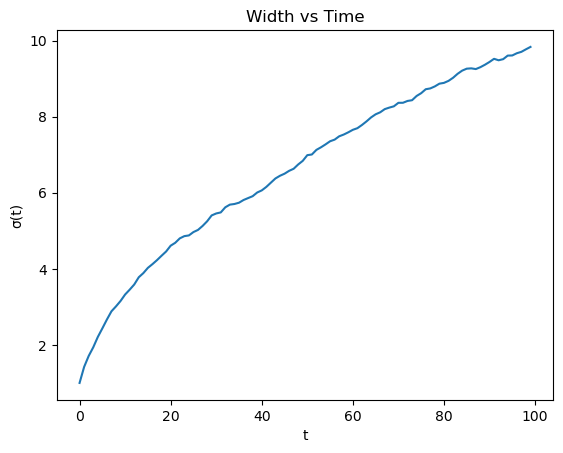

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

n = 100          # number of time steps
l = 1000         # number of random walkers (ensemble size)

L = np.zeros(l)  # initial positions of all walkers (all start at x = 0)
L_t = []         # will store snapshots of full system at each time step

# time evolution loop
for j in range(n):
    for i in range(l):
        r = np.random.random()   # uniform random number in [0,1]

        if r <= 0.5:
            L[i] += 1           # step right (+1)
        else:
            L[i] -= 1           # step left (-1)

    L_t.append(L.copy())        # store full configuration at time j


# function to compute standard deviation (width of distribution)
def sigma(L_snapshot):
    rho = {}  # dictionary for probability distribution P(x)

    # build histogram: count how many walkers at each position
    for pos in L_snapshot:
        rho[pos] = rho.get(pos, 0) + 1

    total = len(L_snapshot)  # total number of walkers

    sigma2 = 0  # will store <x^2>

    # compute second moment: <x^2> = sum x^2 P(x)
    for x, count in rho.items():
        sigma2 += x**2 * (count / total)

    return sigma2**0.5  # σ = sqrt(<x^2>) since mean ≈ 0


sigma_t = []  # store width vs time

# compute width at each time step
for i in range(n):
    sigma_t.append(sigma(L_t[i]))


print(sigma_t)  # print time evolution of width

# plot σ(t)
plt.plot(range(n), sigma_t)
plt.xlabel('t')                 # time
plt.ylabel('σ(t)')              # width (standard deviation)
plt.title('Width vs Time (Random Walk Diffusion)')
plt.show()

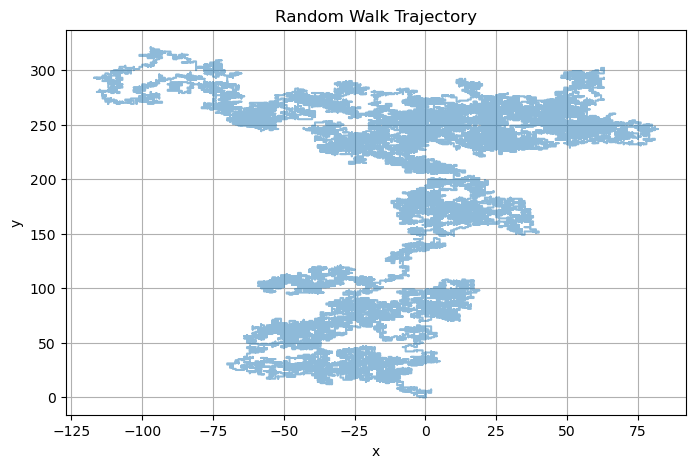

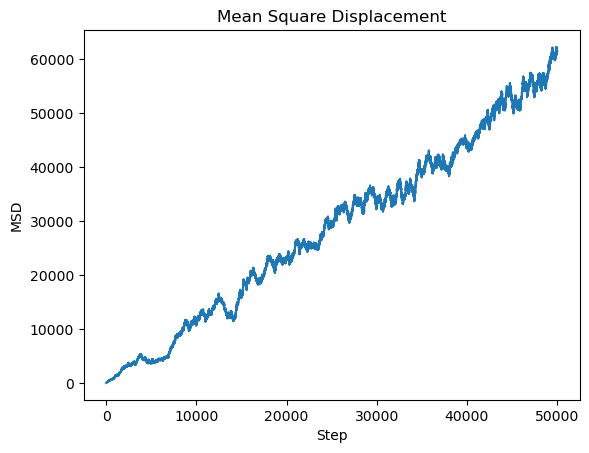

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 50000  # number of time steps
Nre = 10   # number of realizations

# Pre‑allocate array for mean‑square displacement of each realization
msd = np.zeros((N, Nre))
X = np.array(N)  # time steps array
Y = np.array(N)  # time steps array

for ire in range(Nre):
    # walker position arrays (initial position at origin)
    x = np.zeros(N)
    y = np.zeros(N)
    for i in range(1, N):
        ro = np.random.rand()  # orientation selector
        rd = np.random.rand()  # displacement selector
        if ro >= 0.5:
            # move in x direction, y stays the same
            y[i] = y[i-1]
            x[i] = x[i-1] + (1 if rd >= 0.5 else -1)
        else:
            # move in y direction, x stays the same
            x[i] = x[i-1]
            y[i] = y[i-1] + (1 if rd >= 0.5 else -1)
    # squared displacement for this realization
    
    msd[:, ire] = x**2 + y**2
    X = x
    Y = y

# Mean square displacement across realizations
MSD = msd.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(X, Y, alpha=0.5)  # plot one trajectory for visualization
plt.xlabel('x')
plt.ylabel('y')
plt.title('Random Walk Trajectory')
plt.grid()
plt.show()
# Plot the result
plt.plot(MSD)
plt.title('Mean Square Displacement')
plt.xlabel('Step')
plt.ylabel('MSD')
plt.show()


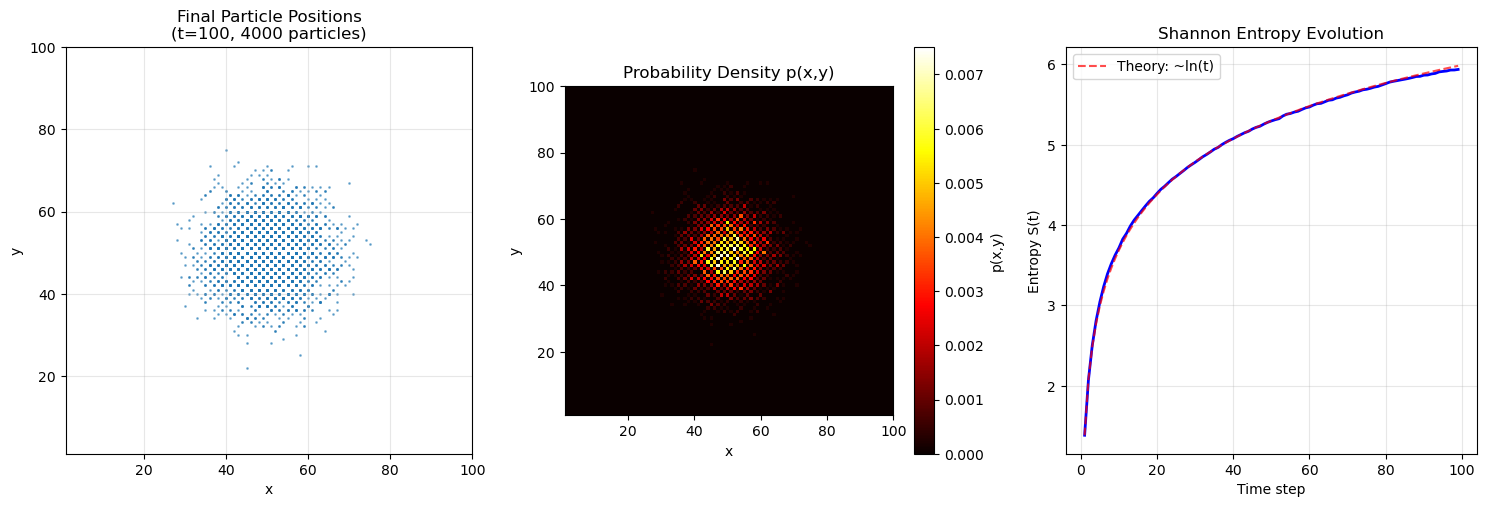

Initial entropy: 1.3862
Final entropy: 5.9361
Max possible (uniform): 9.2103


In [ ]:
"""
Vibe-coded Multi-Particle Random Walk with Entropy
Many walkers + probability density + Shannon entropy
"""

import numpy as np
import matplotlib.pyplot as plt

# === STEP 1: SETUP ===
N = 100        # Number of time steps
Np = 4000      # Number of particles
L = 100        # Lattice size (L x L grid)

# All particle positions: x[time, particle]
x = np.zeros((N, Np), dtype=int)
y = np.zeros((N, Np), dtype=int)
 
# Start all particles at center
x[0, :] = L // 2
y[0, :] = L // 2

# Storage for probability density and entropy
pN_t = np.zeros((L, L, N-1))  # Probability density at each time
S = np.zeros(N-1)             # Entropy at each time

# === STEP 2: SIMULATE ALL PARTICLES ===
for i in range(1, N):
    # Grid to count particles at each site
    c = np.zeros((L, L), dtype=int)

    for ip in range(Np):
        # Same random walk as before
        ro = np.random.rand()
        rd = np.random.rand()

        if ro >= 0.5:
            # Move in x
            y[i, ip] = y[i-1, ip]
            if rd >= 0.5:
                x[i, ip] = x[i-1, ip] + 1
            else:
                x[i, ip] = x[i-1, ip] - 1
        else: 
            # Move in y
            x[i, ip] = x[i-1, ip]
            if rd >= 0.5:
                y[i, ip] = y[i-1, ip] + 1
            else:
                y[i, ip] = y[i-1, ip] - 1

        # === STEP 3: PERIODIC BOUNDARY CONDITIONS ===
        # Wrap around: if > L, go to 1; if < 1, go to L
        # Using modulo (but careful: MATLAB is 1-indexed, Python 0-indexed)
        x[i, ip] = ((x[i, ip] - 1) % L) + 1
        y[i, ip] = ((y[i, ip] - 1) % L) + 1

        # Count this particle on the grid (convert to 0-indexed for array)
        c[x[i, ip]-1, y[i, ip]-1] += 1

    # === STEP 4: COMPUTE PROBABILITY DENSITY ===
    pN_t[:, :, i-1] = c / Np  # Normalize by total particles

    # === STEP 5: COMPUTE SHANNON ENTROPY ===
    # S = -sum(p * ln(p))
    # Handle p=0 by setting ln(0)*0 = 0
    p_flat = pN_t[:, :, i-1].flatten()
    p_nonzero = p_flat[p_flat > 0]  # Only non-zero probabilities
    S[i-1] = -np.sum(p_nonzero * np.log(p_nonzero))

# === STEP 6: VISUALIZE ===
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Final particle positions
axes[0].scatter(x[-1, :], y[-1, :], s=1, alpha=0.5)
axes[0].set_xlim(1, L)
axes[0].set_ylim(1, L)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title(f'Final Particle Positions\n(t={N}, {Np} particles)')
axes[0].set_aspect('equal')
axes[0].grid(True, alpha=0.3)

# Plot 2: Probability density heatmap at final time
im = axes[1].imshow(pN_t[:, :, -1].T, origin='lower', cmap='hot',
                     extent=[1, L, 1, L])
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title('Probability Density p(x,y)')
plt.colorbar(im, ax=axes[1], label='p(x,y)')

# Plot 3: Entropy vs time
axes[2].plot(range(1, N), S, 'b-', linewidth=2)
axes[2].set_xlabel('Time step')
axes[2].set_ylabel('Entropy S(t)')
axes[2].set_title('Shannon Entropy Evolution')
axes[2].grid(True, alpha=0.3)

# Also plot theoretical expectation for diffusion
# For 2D diffusion from point source: variance grows as 2*D*t
# Entropy ~ ln(t) for spreading Gaussian
axes[2].plot(range(1, N), S[0] + np.log(np.arange(1, N)), 'r--',
              label='Theory: ~ln(t)', alpha=0.7)
axes[2].legend()

plt.tight_layout()
plt.savefig('entropy_random_walk.png', dpi=150)
plt.show()

print(f"Initial entropy: {S[0]:.4f}")
print(f"Final entropy: {S[-1]:.4f}")
print(f"Max possible (uniform): {np.log(L*L):.4f}")

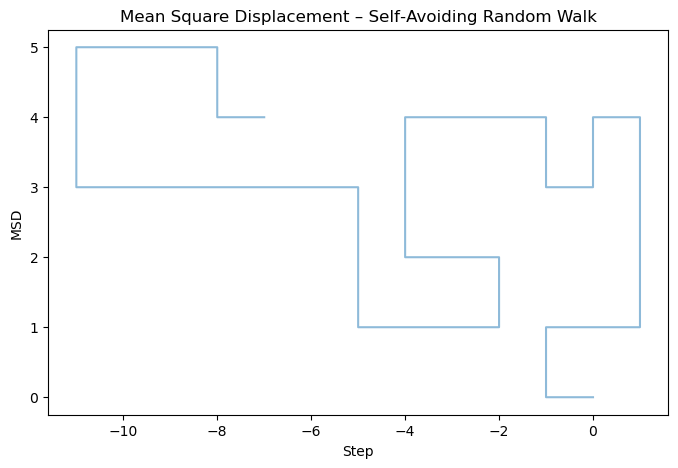

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Parameters -------------------------------------------------
N  = 50000        # maximum number of steps per walk
Nre = 10          # number of realizations

# ---- Storage ----------------------------------------------------
# mean‑square displacement for each realization (same shape as original example)
msd = np.zeros((N, Nre))

for ire in range(Nre):
    # walker position arrays (start at origin)
    x = np.zeros(N, dtype=int)
    y = np.zeros(N, dtype=int)
    # set of visited lattice points (store as tuples)
    visited = {(0, 0)}
    stuck = False

    for i in range(1, N):
        # try to make a move – keep trying until a non‑visited neighbour is found
        # (or give up if all four neighbours are already visited)
        attempts = 0
        while True:
            ro = np.random.rand()   # choose axis (x or y)
            rd = np.random.rand()   # choose direction (+1 / -1)
            dx, dy = (1 if rd >= 0.5 else -1, 0) if ro >= 0.5 else (0, 1 if rd >= 0.5 else -1)
            nx, ny = x[i-1] + dx, y[i-1] + dy
            if (nx, ny) not in visited:
                # valid step
                x[i] = nx
                y[i] = ny
                visited.add((nx, ny))
                break
            else:
                attempts += 1
                if attempts >= 4:
                    # all four neighbours already visited – self‑avoiding walk is stuck
                    stuck = True
                    break
        if stuck:
            # fill remaining steps with the last position (walk ends early)
            x[i:] = x[i-1]
            y[i:] = y[i-1]
            break

    # squared displacement for this realization (up to the point we stopped)
    msd[:, ire] = x**2 + y**2

# ---- Mean square displacement across realizations ----------------
MSD = msd.mean(axis=1)

# ---- Plot -------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(x, y, alpha=0.5)  # plot one trajectory for visualization
# plt.plot(MSD)
plt.title(' – Self‑Avoiding Random Walk')
plt.xlabel('Step')
plt.ylabel('MSD')
plt.show()

Best beta = 0.9874371859296482


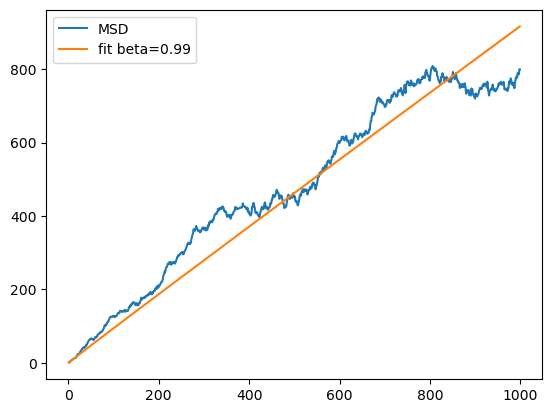

In [14]:
import numpy as np
import matplotlib.pyplot as plt

N = 1000
Nre = 50

msd = np.zeros(N)

for r in range(Nre):
    x = np.zeros(N)
    y = np.zeros(N)

    for t in range(1, N):
        r1 = np.random.rand()
        r2 = np.random.rand()

        if r1 < 0.25:
            x[t] = x[t-1] + 1
            y[t] = y[t-1]
        elif r1 < 0.5:
            x[t] = x[t-1] - 1
            y[t] = y[t-1]
        elif r1 < 0.75:
            x[t] = x[t-1]
            y[t] = y[t-1] + 1
        else:
            x[t] = x[t-1]
            y[t] = y[t-1] - 1

    msd += x**2 + y**2

msd /= Nre

t = np.arange(1, N)

# -----------------------------
# linear search over beta
# -----------------------------
beta_values = np.linspace(0.5, 1.5, 200)

best_beta = 0
best_error = 1e18

for beta in beta_values:
    model = t**beta
    error = np.sum((msd[1:] - model)**2)

    if error < best_error:
        best_error = error
        best_beta = beta

print("Best beta =", best_beta)

# -----------------------------
# plot result
# -----------------------------
plt.plot(t, msd[1:], label="MSD")
plt.plot(t, t**best_beta, label=f"fit beta={best_beta:.2f}")
plt.legend()
plt.show()

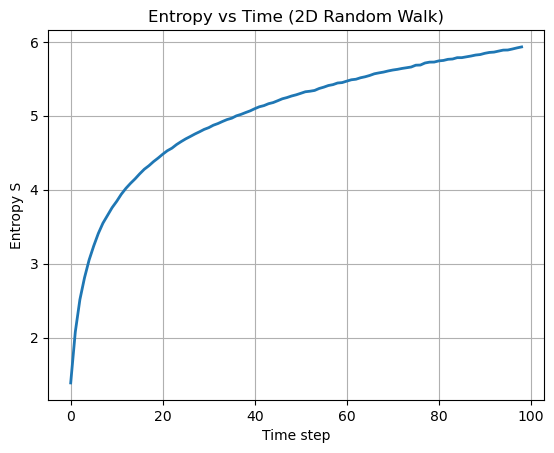

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N  = 100      # time steps
Np = 4000     # number of particles
L  = 100      # lattice size

# Initialize positions (0-based indexing)
x = np.full((N, Np), L//2, dtype=int)
y = np.full((N, Np), L//2, dtype=int)

S = np.zeros(N-1)

for t in range(1, N):
    c = np.zeros((L, L), dtype=int)
    
    for p in range(Np):
        if np.random.rand() >= 0.5:
            # move in x
            x[t, p] = x[t-1, p] + (1 if np.random.rand() >= 0.5 else -1)
            y[t, p] = y[t-1, p]
        else:
            # move in y
            y[t, p] = y[t-1, p] + (1 if np.random.rand() >= 0.5 else -1)
            x[t, p] = x[t-1, p]
        
        # periodic boundary (0 to L-1)
        x[t, p] %= L
        y[t, p] %= L
        
        # direct indexing (no -1!)
        c[x[t, p], y[t, p]] += 1

    # probability distribution
    p_dist = c / Np

    # entropy (safe log)
    p_safe = np.where(p_dist == 0, 1, p_dist)
    S[t-1] = -np.sum(p_dist * np.log(p_safe))

# Plot
plt.plot(S, linewidth=2)
plt.xlabel("Time step")
plt.ylabel("Entropy S")
plt.title("Entropy vs Time (2D Random Walk)")
plt.grid(True)
plt.show()

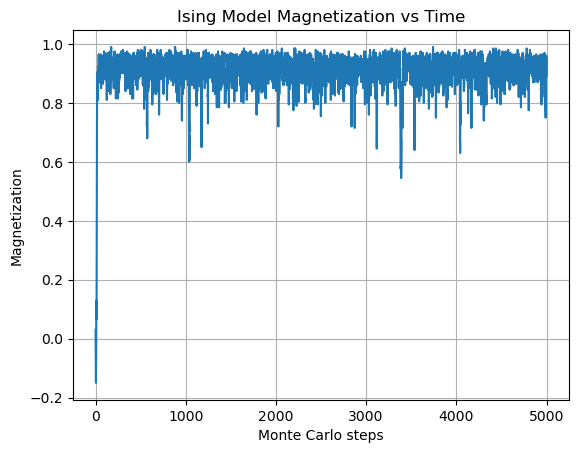

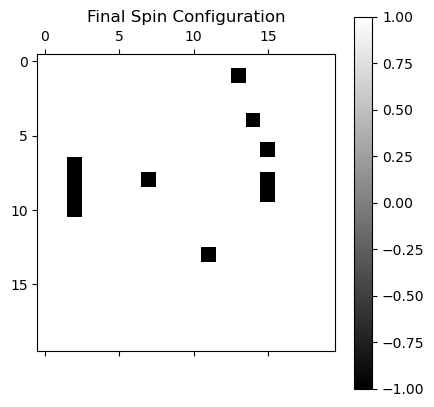

In [14]:
import numpy as np
import matplotlib.pyplot as plt

kb = 1.0   # dimensionless (IMPORTANT)

def ising_simulation(L=20, N=500, T=2.0, J=1.0, h=0.0):
    
    # Initialize spins ±1
    g = np.random.choice([-1, 1], size=(L, L))
    
    M = []
    
    for step in range(N):
        for i in range(L):
            for j in range(L):
                
                # sum of nearest neighbors (periodic BC)
                nn = (
                    g[(i-1)%L, j] + g[(i+1)%L, j] +
                    g[i, (j-1)%L] + g[i, (j+1)%L]
                )
                
                # energy change for flip
                dE = 2 * (J * nn * g[i, j] + h * g[i, j])
                
                # Metropolis condition
                if dE < 0 or np.random.random() < np.exp(-dE/(kb*T)):
                    g[i, j] *= -1
        
        M.append(np.mean(g))
    
    return g, M


# Run
L = 20
N = 5000

g, M = ising_simulation(L=L, N=N, T=2.0)

# Magnetization plot
plt.plot(M)
plt.xlabel("Monte Carlo steps")
plt.ylabel("Magnetization")
plt.title("Ising Model Magnetization vs Time")
plt.grid()
plt.show()

# Final configuration
plt.matshow(g, cmap='gray')
plt.colorbar()
plt.title("Final Spin Configuration")
plt.show()

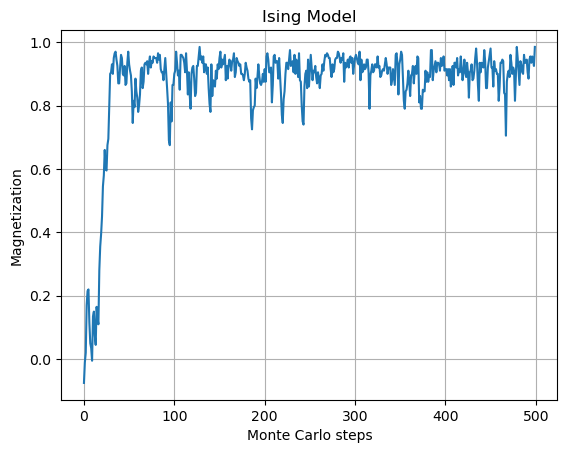

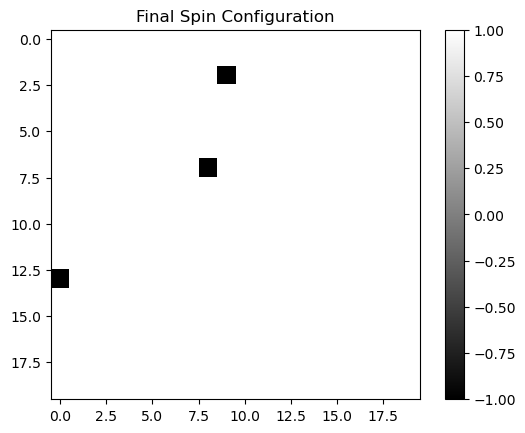

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

L, N, T, J, h = 20, 500, 2.0, 1.0, 0.0

def ice(L, N, T, J, h):
    g = np.random.choice([-1, 1], size=(L, L))
    M = []
    
    for step in range(N):
        for i in range(L):          # FIX: use L
            for j in range(L):      # FIX: use L
                
                # periodic neighbors
                nn = (
                    g[(i+1)%L, j] + g[(i-1)%L, j] +
                    g[i, (j+1)%L] + g[i, (j-1)%L]
                )
                
                # energy change
                dE = 2 * g[i, j] * (J * nn + h)
                
                # Metropolis rule
                if dE < 0 or np.random.rand() < np.exp(-dE / T):
                    g[i, j] *= -1
        
        M.append(np.mean(g))
    
    return g, M


# Run simulation
g, M = ice(L, N, T, J, h)

# Plot magnetization
plt.plot(M)
plt.xlabel("Monte Carlo steps")
plt.ylabel("Magnetization")
plt.title("Ising Model")
plt.grid()
plt.show()

# Final configuration
plt.imshow(g, cmap='gray')
plt.colorbar()
plt.title("Final Spin Configuration")
plt.show()

Magnetization: -0.0019594999999999986
Time: 13.43703293800354


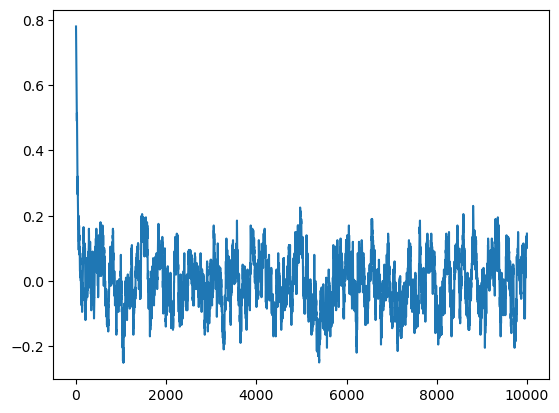

In [21]:
import numpy as np
import time

L = 20          # system size
J = 1.0         # interaction
h = 0.0         # magnetic field
N = 10000       # Monte Carlo steps

j = 0

start = time.time()

for T in [5]:   # temperature loop
    
    # Initialize spins in {+1, -1}
    S = np.random.rand(L, L)
    frac = 0.1
    S[S < frac] = -1
    S[S != -1] = 1
    
    M = []
    ST = np.zeros((N, L, L))
    
    for i in range(N):
        
        for px in range(L):
            
            py = np.random.randint(0, L)  # random site
            
            # periodic boundary conditions (0-based)
            px_r = (px + 1) % L
            px_l = (px - 1) % L
            py_t = (py + 1) % L
            py_b = (py - 1) % L
            
            # neighbor sum
            nn = (
                S[px_r, py] + S[px_l, py] +
                S[px, py_t] + S[px, py_b]
            )
            
            # energies (same structure as MATLAB)
            E1 = -J * S[px, py] * nn + h * S[px, py]
            E2 =  J * S[px, py] * nn - h * S[px, py]
            
            dE = E2 - E1
            
            # Metropolis update
            if dE < 0 or np.random.rand() < np.exp(-dE / T):
                S[px, py] *= -1
        
        ST[i] = S
        M.append(np.mean(S))
    
    mM = np.mean(M)
    temp = T

end = time.time()
print("Magnetization:", mM)
print("Time:", end - start)
plt.plot(M)

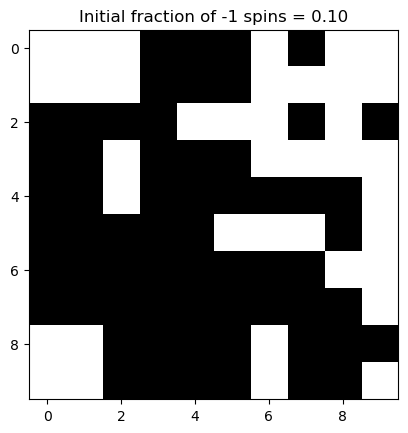

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Parameters
L = 10
J = 1.0
h = 0.0
T = 5.0
steps = 100  # keep small for animation speed

fractions = np.linspace(0.1, 0.9, 30)  # varying initial disorder

def metropolis_step(S):
    for _ in range(L*L):
        i = np.random.randint(0, L)
        j = np.random.randint(0, L)

        nn = (
            S[(i+1)%L, j] + S[(i-1)%L, j] +
            S[i, (j+1)%L] + S[i, (j-1)%L]
        )

        dE = 2 * S[i, j] * (J * nn + h)

        if dE < 0 or np.random.rand() < np.exp(-dE / T):
            S[i, j] *= -1

    return S


# initial frame generator
frames = []

for frac in fractions:
    S = np.random.rand(L, L)
    S[S < frac] = -1
    S[S != -1] = 1

    history = []

    for _ in range(steps):
        S = metropolis_step(S)
        history.append(S.copy())

    frames.append(history[-1])  # final state for each frac


# --- ANIMATION SETUP ---
fig, ax = plt.subplots()
img = ax.imshow(frames[0], cmap="gray", vmin=-1, vmax=1)
title = ax.set_title("frac = 0.1")

def update(frame_idx):
    img.set_data(frames[frame_idx])
    title.set_text(f"Initial fraction of -1 spins = {fractions[frame_idx]:.2f}")
    return [img, title]

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(frames),
    interval=200,
    blit=False
)
ani.save("spin_fraction_animation.mp4",              
     writer=animation.FFMpegWriter(fps=5), dpi=10)


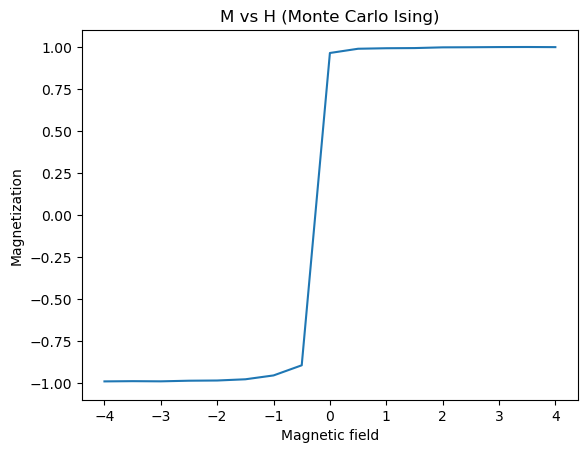

In [15]:
import numpy as np
import matplotlib.pyplot as plt

L, N, T, J = 10, 2000, 1.7, 1.0

def ice(L, N, T, J):
    H_vals = []
    mM_vals = []

    for h in np.arange(-4, 4.5, 0.5):  # magnetic field loop
        
        # initial spins (same idea as MATLAB)
        S = np.random.rand(L, L)
        frac = 0.1
        S[S < frac] = -1
        S[S != -1] = 1

        M = []

        for step in range(N):  # Monte Carlo steps
            
            for px in range(L):  # spatial loop
                
                py = np.random.randint(0, L)  # random site
                
                # periodic boundary conditions
                px_r = (px + 1) % L
                px_l = (px - 1) % L
                py_t = (py + 1) % L
                py_b = (py - 1) % L

                nn = (S[px_r, py] + S[px_l, py] +
                      S[px, py_t] + S[px, py_b])

                # SAME as your first MATLAB code (correct physics)
                E1 = -J * S[px, py] * nn - h * S[px, py]
                E2 =  J * S[px, py] * nn + h * S[px, py]

                dE = E2 - E1

                if dE < 0 or np.random.random() < np.exp(-dE / T):
                    S[px, py] *= -1

            M.append(np.mean(S))  # magnetization

        mM = np.mean(M)  # average over MC steps
        
        H_vals.append(h)
        mM_vals.append(mM)

    return H_vals, mM_vals


H, mM = ice(L, N, T, J)

plt.plot(H, mM)
plt.ylim([-1.1, 1.1])
plt.xlabel("Magnetic field")
plt.ylabel("Magnetization")
plt.title("M vs H (Monte Carlo Ising)")
plt.show()

extra?

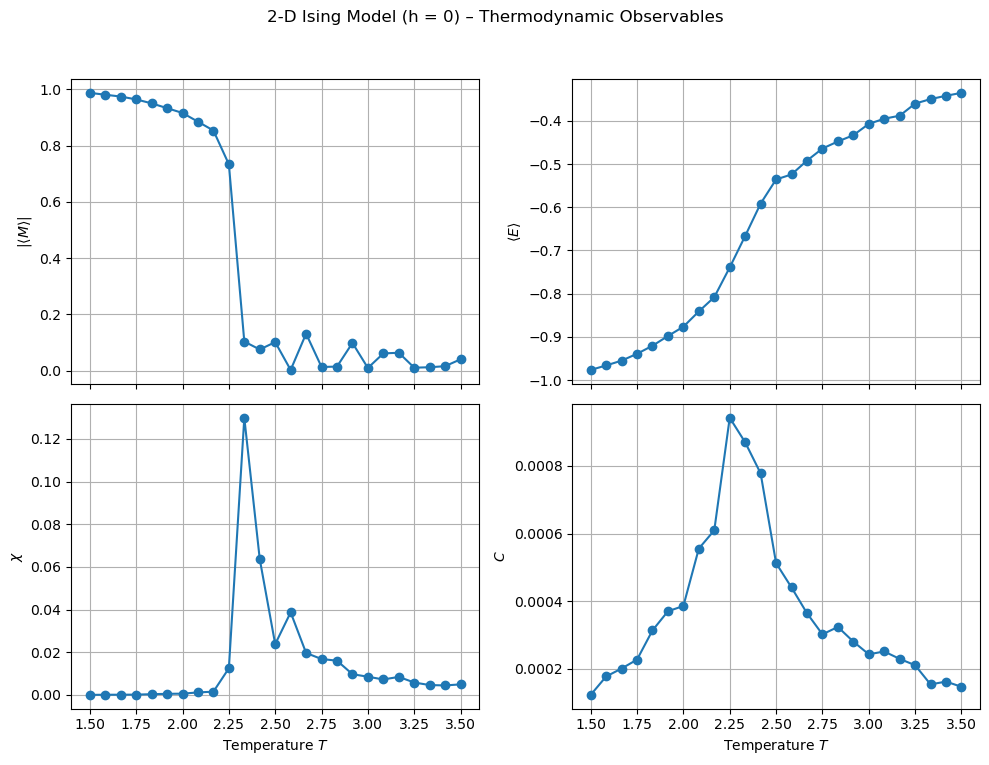

In [17]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Ising model (2‑D, nearest‑neighbour, h = 0) – Monte‑Carlo (Metropolis)

For each temperature T we compute
    ⟨M⟩  – average magnetisation per spin
    ⟨E⟩  – average energy   per spin
    χ     – magnetic susceptibility  = β (⟨M²⟩‑⟨M⟩²)
    C     – specific heat           = β² (⟨E²⟩‑⟨E⟩²)

All quantities are returned as arrays indexed by the temperature list.
"""

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# Simulation parameters (feel free to change)
# ----------------------------------------------------------------------
L = 20               # lattice size (L×L)
N_eq = 200          # equilibration sweeps
N_mc = 800         # measurement sweeps
J = 1.0              # coupling constant
h = 0.0              # external field (fixed to 0)

# ----------------------------------------------------------------------
# Helper: periodic‑boundary neighbour sum
# ----------------------------------------------------------------------
def neighbour_sum(s, i, j):
    """Sum of the four nearest neighbours of spin s[i,j] with periodic BC."""
    return (
        s[(i + 1) % L, j] +
        s[(i - 1) % L, j] +
        s[i, (j + 1) % L] +
        s[i, (j - 1) % L]
    )

# ----------------------------------------------------------------------
# Core Monte‑Carlo routine
# ----------------------------------------------------------------------
def ising_mc(T):
    """Run Metropolis MC at temperature T (h = 0) and return observables.

    Returns
    -------
    M_avg : float
        Average magnetisation per spin.
    E_avg : float
        Average energy per spin.
    chi   : float
        Magnetic susceptibility.
    C     : float
        Specific heat.
    """
    beta = 1.0 / T
    # start from a random configuration
    spins = np.random.choice([-1, 1], size=(L, L))

    # ------------------- equilibration ---------------------------------
    for _ in range(N_eq):
        for _ in range(L * L):
            i = np.random.randint(0, L)
            j = np.random.randint(0, L)
            delta_E = 2 * J * spins[i, j] * neighbour_sum(spins, i, j)  # ΔE = E_new‑E_old
            if delta_E <= 0 or np.random.rand() < np.exp(-beta * delta_E):
                spins[i, j] *= -1

    # ------------------- measurement ------------------------------------
    m_vals = []      # magnetisation per spin
    e_vals = []      # energy per spin
    for _ in range(N_mc):
        for _ in range(L * L):
            i = np.random.randint(0, L)
            j = np.random.randint(0, L)
            delta_E = 2 * J * spins[i, j] * neighbour_sum(spins, i, j)
            if delta_E <= 0 or np.random.rand() < np.exp(-beta * delta_E):
                spins[i, j] *= -1

        # after a full sweep record observables
        m = np.mean(spins)                      # M/N
        # energy: -J * sum_{⟨ij⟩} s_i s_j  (each bond counted once)
        e = -J * np.sum(
            spins * (
                np.roll(spins, 1, axis=0) +   # vertical neighbours
                np.roll(spins, 1, axis=1)     # horizontal neighbours
            )
        ) / (2 * L * L)                         # divide by 2 to avoid double‑counting
        m_vals.append(m)
        e_vals.append(e)

    m_arr = np.array(m_vals)
    e_arr = np.array(e_vals)

    # ensemble averages
    M_avg = np.mean(m_arr)
    E_avg = np.mean(e_arr)

    # fluctuations needed for χ and C
    chi = beta * (np.mean(m_arr**2) - M_avg**2)
    C   = beta**2 * (np.mean(e_arr**2) - E_avg**2)

    return M_avg, E_avg, chi, C

# ----------------------------------------------------------------------
# Sweep over temperatures
# ----------------------------------------------------------------------
temps = np.linspace(1.5, 3.5, 25)   # typical range around the 2‑D critical point (≈2.269)
M_T, E_T, chi_T, C_T = [], [], [], []

for T in temps:
    M, E, chi, C = ising_mc(T)
    M_T.append(M)
    E_T.append(E)
    chi_T.append(chi)
    C_T.append(C)

M_T   = np.array(M_T)
E_T   = np.array(E_T)
chi_T = np.array(chi_T)
C_T   = np.array(C_T)

# ----------------------------------------------------------------------
# Plot results
# ----------------------------------------------------------------------
fig, axs = plt.subplots(2, 2, figsize=(10, 8), sharex=True)

axs[0, 0].plot(temps, np.abs(M_T), 'o-')
axs[0, 0].set_ylabel(r'$|\langle M\rangle|$')
axs[0, 0].grid(True)

axs[0, 1].plot(temps, E_T, 'o-')
axs[0, 1].set_ylabel(r'$\langle E\rangle$')
axs[0, 1].grid(True)

axs[1, 0].plot(temps, chi_T, 'o-')
axs[1, 0].set_xlabel('Temperature $T$')
axs[1, 0].set_ylabel(r'$\chi$')
axs[1, 0].grid(True)

axs[1, 1].plot(temps, C_T, 'o-')
axs[1, 1].set_xlabel('Temperature $T$')
axs[1, 1].set_ylabel(r'$C$')
axs[1, 1].grid(True)

fig.suptitle('2‑D Ising Model (h = 0) – Thermodynamic Observables')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

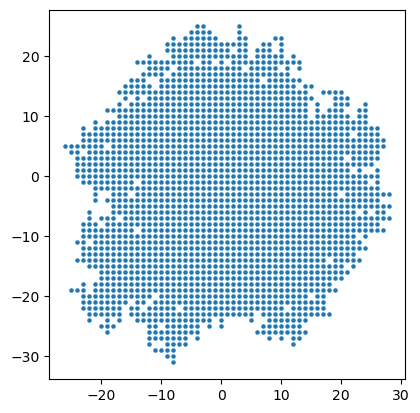

In [44]:
import numpy as np
import matplotlib.pyplot as plt

N = 2000

def eden(N):
    cluster = set([(0,0)])
    perimeter = set([(1,0),(-1,0),(0,1),(0,-1)])

    for _ in range(N):
        x,y = list(perimeter)[np.random.randint(len(perimeter))]
        cluster.add((x,y))
        perimeter.remove((x,y))

        for dx,dy in [(1,0),(-1,0),(0,1),(0,-1)]:
            nb = (x+dx, y+dy)
            if nb not in cluster:
                perimeter.add(nb)

    return np.array(list(cluster))

c = eden(N)

plt.scatter(c[:,0], c[:,1], s=5)
plt.gca().set_aspect('equal')
plt.show()

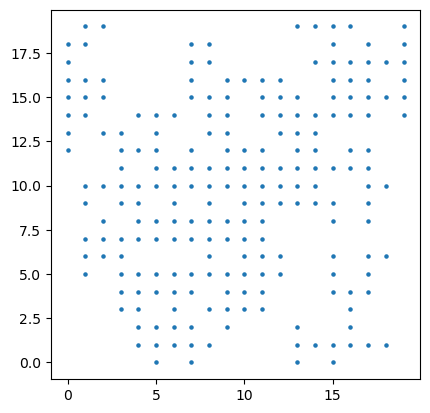

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

L, N = 200, 300

def dla(L, N): #diffusde limited aggregation    
    g = np.zeros((L, L))
    c = L//2
    g[c, c] = 1

    for _ in range(N):
        x = np.random.randint(L)
        y = np.random.randint(L)

        while True: error. You would need to write it as peripheral[x][y].

            if g[x, (y+1)%L] or g[x, (y-1)%L] or g[(x+1)%L, y] or g[(x-1)%L, y]:
                g[x, y] = 1
                break

            r = np.random.randint(4)
            if r == 0: x = (x+1)%L
            if r == 1: x = (x-1)%L
            if r == 2: y = (y+1)%L
            if r == 3: y = (y-1)%L

    return g

g = dla(L, N)

x, y = np.where(g == 1)
plt.scatter(x, y, s=5)
plt.gca().set_aspect('equal')
plt.show()

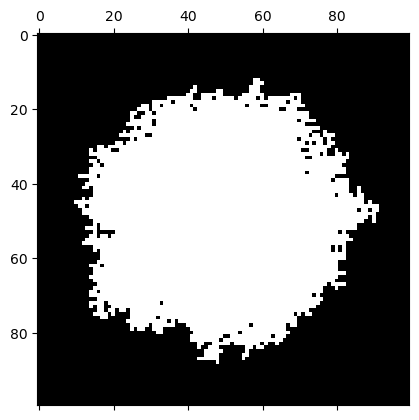

In [88]:
# Eden Growth

import numpy as np
import matplotlib.pyplot as plt

L = 100
N = 4000

mat = np.zeros((L, L)) # stores where the cluster has grown to
mat[L//2, L//2] = 1

peripheral = np.zeros((L, L)) # stores the sites where the cluster can grow to in the next step

peripheral[(L//2+1)%L, L//2] = 1
peripheral[(L//2-1)%L, L//2] = 1
peripheral[L//2, (L//2+1)%L] = 1
peripheral[L//2, (L//2-1)%L] = 1

for n in range(N):
    # search for all the sites where peripheral == 1
    i_index = []
    j_index = []
    for i in range(L):
        for j in range(L):
            if peripheral[i, j] == 1:
                i_index.append(i)
                j_index.append(j)

    # select a random site from the peripheral sites
    r = np.random.randint(0, len(i_index))
    i, j = i_index[r], j_index[r]

    mat[i, j] = 1 # grow the cluster to this site

    # update the peripheral sites
    peripheral[i, j] = 0

    if mat[(i+1)%L, j] == 0:
        peripheral[(i+1)%L, j] = 1
    if mat[(i-1)%L, j] == 0:
        peripheral[(i-1)%L, j] = 1
    if mat[i, (j+1)%L] == 0:
        peripheral[i, (j+1)%L] = 1
    if mat[i, (j-1)%L] == 0:
        peripheral[i, (j-1)%L] = 1
    
    # if mat[i+1, j] == 0:
    #     peripheral[i+1, j] = 1
    # if mat[i-1, j] == 0:
    #     peripheral[i-1, j] = 1
    # if mat[i, j+1] == 0:
    #     peripheral[i, j+1] = 1
    # if mat[i, j-1] == 0:
    #     peripheral[i, j-1] = 1
    
plt.matshow(mat, cmap='gray')
plt.axis('equal')
plt.show()

DFA

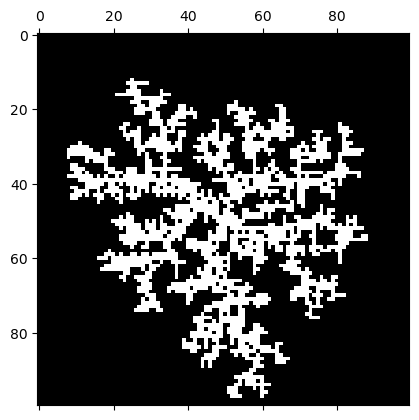

In [1]:
# Diffusion Limited Aggregation

import numpy as np
import matplotlib.pyplot as plt

L = 100
N = 2000

mat = np.zeros((L, L)) # matrix to store where the cluster has grown to
mat[L//2, L//2] = 1

for n in range(N):
    # select a random site on the lattice that is not occupied by the cluster
    while True:
        i = np.random.randint(0, L)
        j = np.random.randint(0, L)
        if mat[i, j] == 0:
            break
    
    # start a random walk from this site until it hits the cluster
    pos = np.array([i, j])
    while True:
        r = np.random.randint(0, 4)
        if r == 0:
            dir = np.array([1, 0])
        elif r == 1:
            dir = np.array([-1, 0])
        elif r == 2:
            dir = np.array([0, 1])
        else:
            dir = np.array([0, -1])
        next_pos = (pos + dir) % L

        if mat[next_pos[0], next_pos[1]] == 1: # if the next position is occupied by the cluster, then we can grow the cluster to the current position
            i, j = pos
            mat[i, j] = 1
            break
        else:
            pos = next_pos

plt.matshow(mat, cmap='gray')
plt.show()

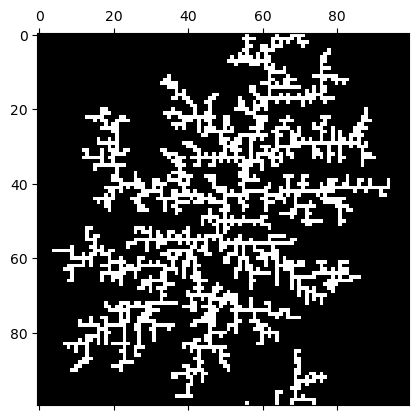

In [6]:
import numpy as np
import matplotlib.pyplot as plt

L = 100
N = 2000

mat = np.zeros((L, L))
mat[L//2, L//2] = 1   # seed at center

for n in range(N):

    # pick a random empty starting point
    while True:
        x = np.random.randint(0, L)
        y = np.random.randint(0, L)
        if mat[x, y] == 0:
            break

    # random walk
    while True:
        r1 = np.random.rand()
        r2 = np.random.rand()

        # move like your random walk code
        if r1 >= 0.5:
            ny = y
            nx = x + (1 if r2 >= 0.5 else -1)
        else:
            nx = x
            ny = y + (1 if r2 >= 0.5 else -1)

        # periodic boundary
        nx = nx % L
        ny = ny % L

        # check neighbors (Eden-style thinking)
        if (mat[(nx+1)%L, ny] == 1 or
            mat[(nx-1)%L, ny] == 1 or
            mat[nx, (ny+1)%L] == 1 or
            mat[nx, (ny-1)%L] == 1):

            mat[nx, ny] = 1
            break
        else:
            x, y = nx, ny

plt.matshow(mat, cmap='gray')
plt.show()

In [ ]:
# bisection method

import numpy as np

def f(x):
    return np.sin(x) - 6*x - 5

tolerance = 1e-5

guess = np.array([-2, 0], dtype=float)

no_of_trials = 1000

f_x = f(guess)

if f_x[0] * f_x[1] > 0:
    print("The function has the same signs at the endpoints. Please choose different endpoints.")

for i in range(no_of_trials):
    midpoint = (guess[0] + guess[1]) / 2
    f_midpoint = f(midpoint)

    if abs(f_midpoint) < tolerance:
        print(f"The root is approximately: {midpoint:.4f}")
        break

    f_x = f(guess)

    if f_x[0] * f_midpoint < 0:
        guess[1] = midpoint
    else:
        guess[0] = midpoint

The root is approximately: -0.9709


In [8]:
# newton rhapson method

import numpy as np

def f(x):
    return x**2 - 2*x - 2

def df_dx(x):
    return 2*x - 2

tolerance = 1e-5

guess = -1.0

no_of_trials = 1000

for i in range(no_of_trials):

    f_guess = f(guess)

    df_guess = df_dx(guess)

    if abs(f_guess) < tolerance:
        print(f"The root is approximately: {guess:.4f}")
        break

    if df_guess == 0:
        print("Derivative is zero. No solution found.")
        break

    guess = guess - f_guess / df_guess

The root is approximately: -0.7321


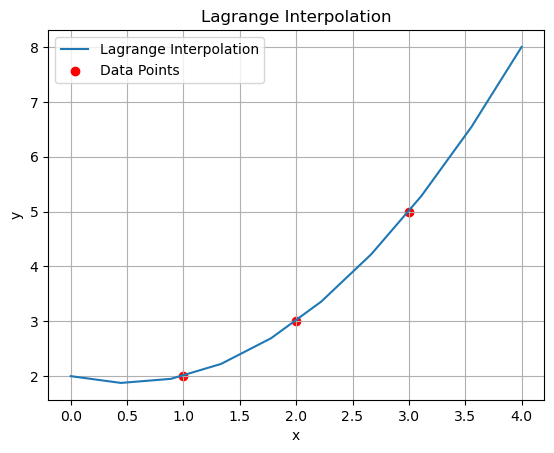

[2.         1.87654321 1.95061728 2.22222222 2.69135802 3.35802469
 4.22222222 5.28395062 6.54320988 8.        ]


In [20]:
# Lagrange interpolation

import numpy as np
import matplotlib.pyplot as plt

x_vals = np.array([1, 2, 3], dtype=float)
y_vals = np.array([2, 3, 5], dtype=float)

def Lagrange_interpolation(x_vals, y_vals):
    def P(x):
        total = 0
        n = len(x_vals)
        for i in range(n):
            term = y_vals[i]
            for j in range(n):
                if j != i:
                    term *= (x - x_vals[j]) / (x_vals[i] - x_vals[j])
            total += term
        return total

    return P

P = Lagrange_interpolation(x_vals, y_vals)

x = np.linspace(0, 4, 10)

plt.plot(x, P(x), label='Lagrange Interpolation')
plt.scatter(x_vals, y_vals, color='red', label='Data Points')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Lagrange Interpolation')
plt.legend()
plt.grid(True)
plt.show()
print(P(x))

In [10]:
# midpoint rule
import numpy as np

def f(x):
    return np.cos(x)


a = 0
b = np.pi / 2

n = 10

h = (b - a) / n

total = 0.0
for i in range(n):
    x_i = a + (i + 0.5) * h
    total += f(x_i)

integral = total * h

print(f"The approximate value of the integral is: {integral:.4f}")


The approximate value of the integral is: 1.0010


In [11]:
# trapezoidal rule
import numpy as np

def f(x):
    return np.cos(x)


a = 0
b = np.pi / 2

n = 10

h = (b - a) / n

total = 0.0
for i in range(n + 1):
    x_i = a + i * h
    if i == 0 or i == n:
        total += f(x_i) / 2
    else:
        total += f(x_i)

integral = total * h

print(f"The approximate value of the integral is: {integral:.4f}")

The approximate value of the integral is: 0.9979


In [13]:
# simpsons 1/3 rule
import numpy as np

def f(x):
    return np.cos(x)


a = 0
b = np.pi / 2

n = 10

h = (b - a) / n

total = 0.0
for i in range(n + 1):
    x_i = a + i * h
    if i == 0 or i == n:
        total += f(x_i)
    elif i % 2 == 0:
        total += 2 * f(x_i)
    else:
        total += 4 * f(x_i)

integral = (h / 3) * total
print(f"The approximate value of the integral is: {integral:.4f}")

The approximate value of the integral is: 1.0000
